## Stage 1: Data Preparation

### Task 1: Load Packages

In [1]:
import os
import shutil
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import xml.etree.ElementTree as ET
from IPython.display import Image
from sklearn.model_selection import train_test_split
import kagglehub

### Task 2: Download the Dataset

In [2]:
path = kagglehub.dataset_download("aslanahmedov/number-plate-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'number-plate-detection' dataset.
Path to dataset files: /kaggle/input/number-plate-detection


### Task 3: Explore the Dataset

In [3]:
# walk the dataset directory and print its structure
for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")

images_dir = None
annotations_dir = None

for root, dirs, files in os.walk(path):
    if any(f.lower().endswith((".png", ".jpg", ".jpeg")) for f in files):
        images_dir = root
    if any(f.lower().endswith(".xml") for f in files):
        annotations_dir = root

print("\nImages directory:", images_dir)
print("Annotations directory:", annotations_dir)

/kaggle/input/number-plate-detection -> 1 files
/kaggle/input/number-plate-detection/images -> 453 files
/kaggle/input/number-plate-detection/TEST -> 2 files

Images directory: /kaggle/input/number-plate-detection/TEST
Annotations directory: /kaggle/input/number-plate-detection/images


### Task 4: Explore the Annotation Format


In [4]:
xml_files = sorted(f for f in os.listdir(annotations_dir) if f.endswith(".xml"))
sample_xml = xml_files[0]
sample_base = os.path.splitext(sample_xml)[0]
annotation_path = os.path.join(annotations_dir, sample_xml)

with open(annotation_path, "r") as file:
    print(file.read())

<annotation>
	<folder></folder>
	<filename>N1.jpeg</filename>
	<path>/Users/asik/Desktop/ANPR/images/N1.jpeg</path>
	<source>
		<database>Unknown</database>
	</source>
	<size>
		<width>1920</width>
		<height>1080</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>number_plate</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>1093</xmin>
			<ymin>645</ymin>
			<xmax>1396</xmax>
			<ymax>727</ymax>
		</bndbox>
	</object>
</annotation>



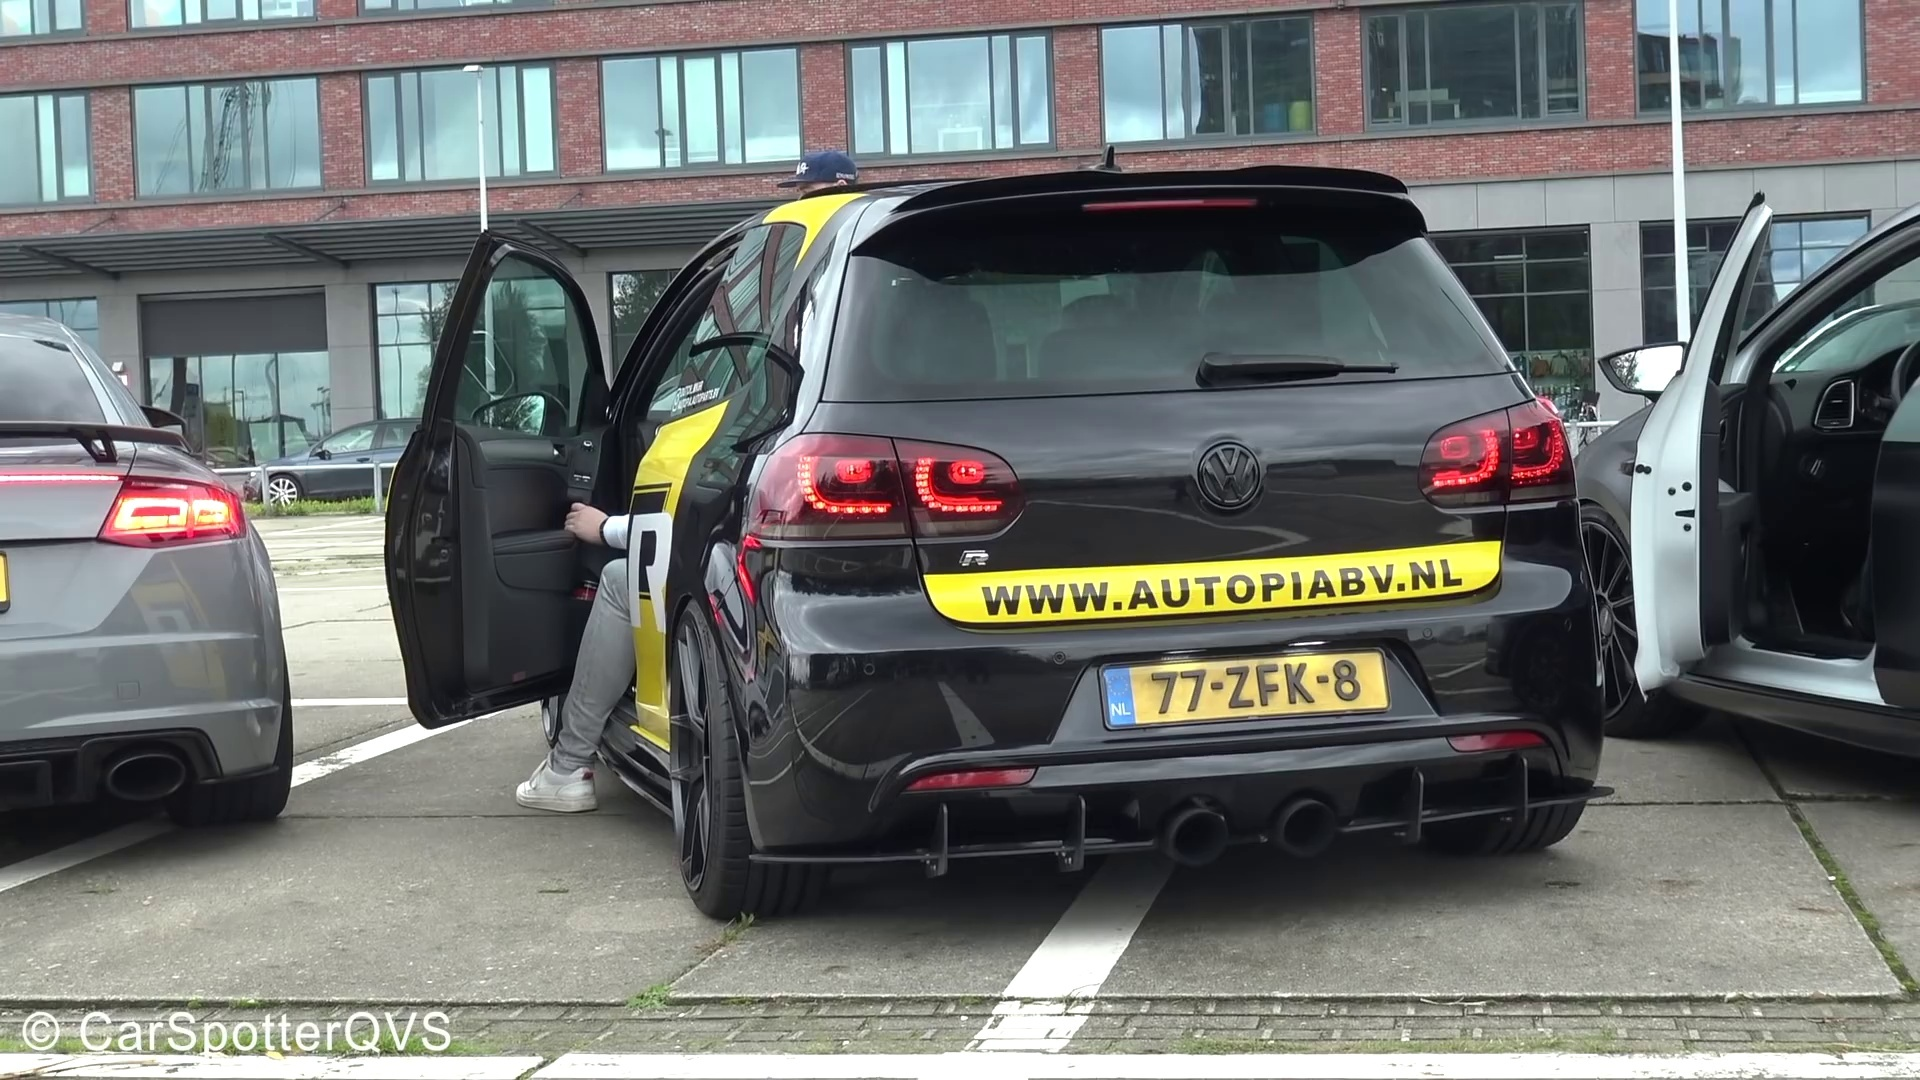

In [5]:
# displaying the corresponding image
possible_exts = [".png", ".jpg", ".jpeg"]
image_path = None
for ext in possible_exts:
    candidate = os.path.join(annotations_dir, sample_base + ext)
    if os.path.exists(candidate):
        image_path = candidate
        break

Image(filename=image_path)

### Task 5: Visualise a Bounding Box


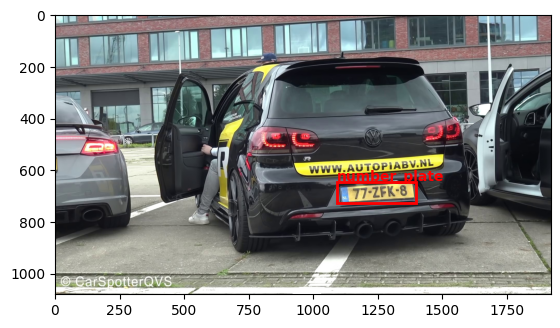

In [6]:
# defining plot_box() and call it

def plot_box(image_path, annotation_path):
    img = plt.imread(image_path)
    fig, ax = plt.subplots(1)
    ax.imshow(img)

    tree = ET.parse(annotation_path)
    root = tree.getroot()

    for obj in root.findall("object"):
        name = obj.find("name").text
        bndbox = obj.find("bndbox")

        xmin = int(float(bndbox.find("xmin").text))
        ymin = int(float(bndbox.find("ymin").text))
        xmax = int(float(bndbox.find("xmax").text))
        ymax = int(float(bndbox.find("ymax").text))

        width = xmax - xmin
        height = ymax - ymin

        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor="r", facecolor="none")
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, name, color="red", fontsize=10, weight="bold")

    plt.show()

plot_box(image_path, annotation_path)

### Task 6: Build the Image List and Split into Train / Val / Test


In [7]:
# building the image list and split into train / val / test

# Not every image necessarily has a matching XML annotation (some datasets
# ship a handful of unlabelled "extra" images). Keep only images that do.
annotated_basenames = {os.path.splitext(f)[0] for f in os.listdir(annotations_dir) if f.endswith(".xml")}

all_candidate_images = [f for f in os.listdir(annotations_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
all_images = [f for f in all_candidate_images if os.path.splitext(f)[0] in annotated_basenames]

skipped = len(all_candidate_images) - len(all_images)
print(f"{len(all_images)} images have a matching XML annotation ({skipped} images skipped, no annotation found).")

train_val_images, test_images = train_test_split(all_images, test_size=0.20, random_state=42)
train_images, val_images = train_test_split(train_val_images, test_size=0.15, random_state=42)

print(f"Train size: {len(train_images)}")
print(f"Validation size: {len(val_images)}")
print(f"Test size: {len(test_images)}")

225 images have a matching XML annotation (3 images skipped, no annotation found).
Train size: 153
Validation size: 27
Test size: 45


### Task 7: Organise the Folder Structure


In [8]:
# defining copy_files() and call it for all three splits

DATASET_ROOT = "/LicensePlateDetection"

def copy_files(img_list, source_folder, target_folder):
    os.makedirs(target_folder, exist_ok=True)
    for img in img_list:
        shutil.copy(os.path.join(source_folder, img), os.path.join(target_folder, img))

# Call the function for train, val, and test
copy_files(train_images, annotations_dir, f"{DATASET_ROOT}/images/train/")
copy_files(val_images, annotations_dir, f"{DATASET_ROOT}/images/val/")
copy_files(test_images, annotations_dir, f"{DATASET_ROOT}/images/test/")

In [9]:
print(os.listdir("/LicensePlateDetection/images/train/")[:5])

['N220.jpeg', 'N80.jpeg', 'N185.jpeg', 'N61.jpeg', 'N45.jpeg']


### Task 8: Discover the Class List


In [10]:
# defining the classes list by scanning all annotation files
unique_classes = set()

for xml_file in os.listdir(annotations_dir):
    if not xml_file.endswith(".xml"):
        continue
    tree = ET.parse(os.path.join(annotations_dir, xml_file))
    root = tree.getroot()
    for obj in root.findall("object"):
        unique_classes.add(obj.find("name").text)

classes = sorted(unique_classes)
print(classes)

['num_plate', 'number_plate']


### Task 9: Build the YOLO Config File

In [11]:
# building the config dictionary and write to YAML

config = {
    "path": DATASET_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(classes),
    "names": classes
}

with open("plate_detection.yaml", "w") as f:
    yaml.dump(config, f, default_flow_style=False)

In [12]:
with open("plate_detection.yaml", "r") as f:
    print(f.read())

names:
- num_plate
- number_plate
nc: 2
path: /LicensePlateDetection
test: images/test
train: images/train
val: images/val



### Task 10: Convert XML Annotations to YOLO Format


In [13]:
# converting all XML annotations to YOLO .txt format

def convert_annotation(xml_path, output_txt_path, image_width, image_height):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    with open(output_txt_path, "w") as f:
        for obj in root.findall("object"):
            name = obj.find("name").text
            if name not in classes:
                continue

            class_id = classes.index(name)
            bndbox = obj.find("bndbox")

            xmin = float(bndbox.find("xmin").text)
            ymin = float(bndbox.find("ymin").text)
            xmax = float(bndbox.find("xmax").text)
            ymax = float(bndbox.find("ymax").text)

            x_center = (xmin + xmax) / (2.0 * image_width)
            y_center = (ymin + ymax) / (2.0 * image_height)
            width = (xmax - xmin) / image_width
            height = (ymax - ymin) / image_height

            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

for split in ("train", "val", "test"):
    os.makedirs(f"{DATASET_ROOT}/labels/{split}/", exist_ok=True)

def process_split(img_list, split_name):
    for img_name in img_list:
        base_name = os.path.splitext(img_name)[0]
        xml_path = os.path.join(annotations_dir, f"{base_name}.xml")
        txt_path = f"{DATASET_ROOT}/labels/{split_name}/{base_name}.txt"

        # Task 6 already filtered all_images down to ones with a matching XML,
        # so this should never trigger
        if not os.path.exists(xml_path):
            print(f"Warning: XML annotation file not found for image {img_name}. Skipping.")
            continue

        tree = ET.parse(xml_path)
        root = tree.getroot()
        size = root.find("size")
        img_w = int(size.find("width").text)
        img_h = int(size.find("height").text)

        convert_annotation(xml_path, txt_path, img_w, img_h)

process_split(train_images, "train")
process_split(val_images, "val")
process_split(test_images, "test")

In [14]:
sample_label = os.listdir(f"{DATASET_ROOT}/labels/train/")[0]
with open(f"{DATASET_ROOT}/labels/train/{sample_label}") as f:
    print(f.read())

1 0.327049 0.555670 0.204918 0.084536



## Stage 2: Training

### Task 11: Clone YOLOv5 and Install Dependencies

In [15]:
# cloning the YOLOv5 repository and install its dependencies
!git clone https://github.com/ultralytics/yolov5
!pip install -r yolov5/requirements.txt

fatal: destination path 'yolov5' already exists and is not an empty directory.


### Task 12: Train the Model


In [16]:
# running the YOLOv5 training script
!python yolov5/train.py \
    --img 416 \
    --batch 16 \
    --epochs 50 \
    --data plate_detection.yaml \
    --weights yolov5s.pt \
    --name plate_run

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 3
wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=plate_detection.yaml, hyp=yolov5/data/hyps/hyp.scratch-low.yaml, epochs=50, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=yolov5/data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=yolov5/runs/train, name=plate_run, exist_ok=False, quad=False, cos_lr=False, label_smooth

### Task 13: Review the Training Curves


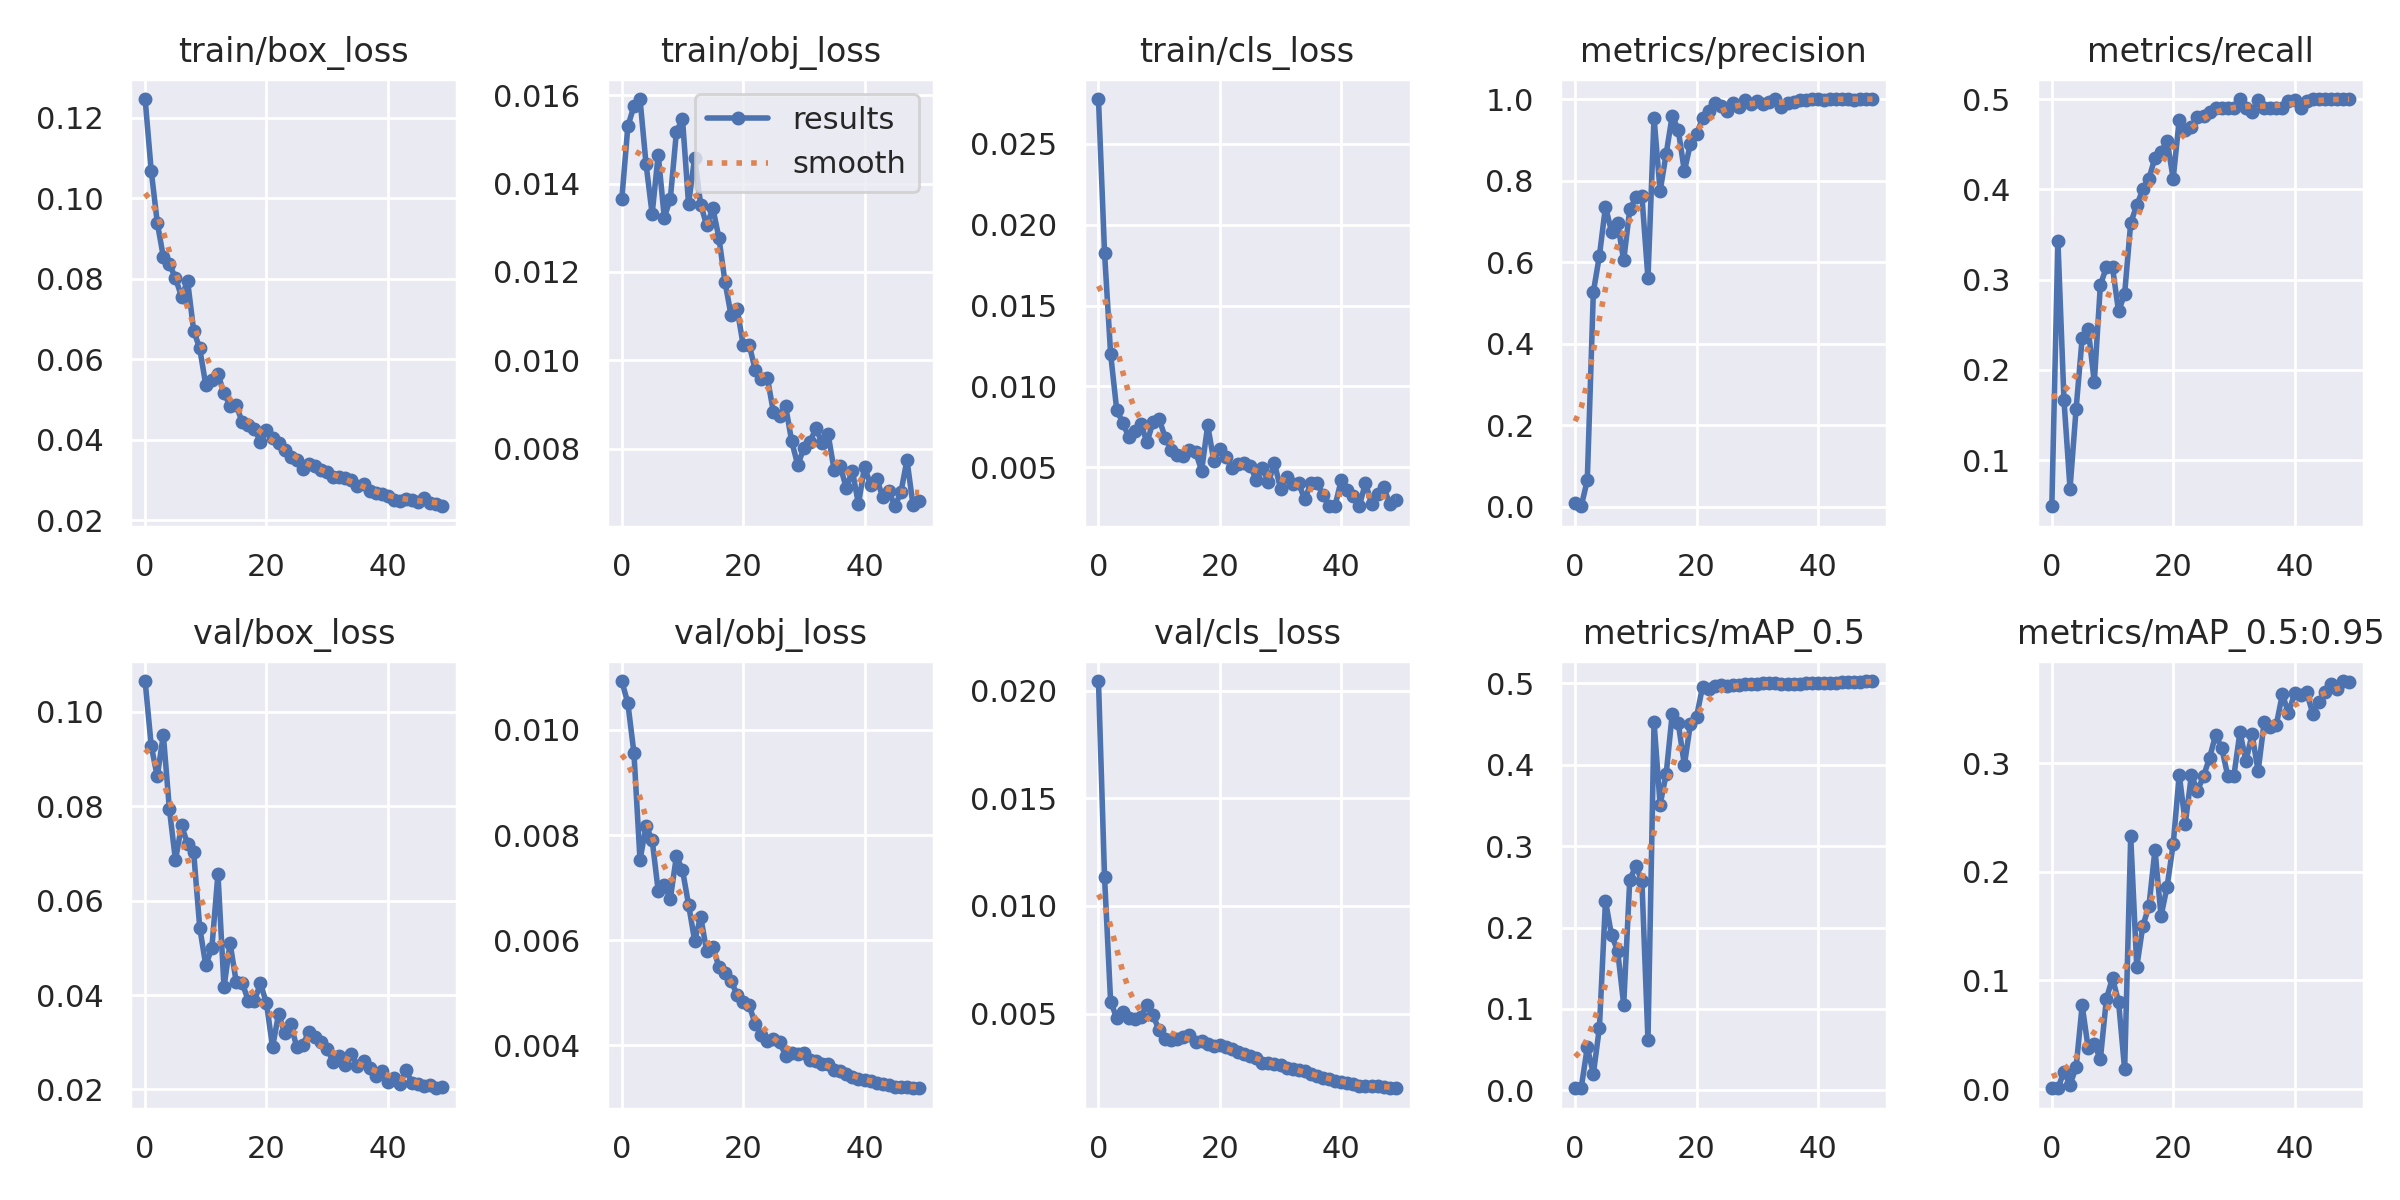

In [17]:
# displaying the results plot generated by YOLOv5
results_path = "yolov5/runs/train/plate_run/results.png"
Image(results_path)

---
## Stage 3: Inference
---

### Task 14: Run Inference on the Test Set

I Use `detect.py` to run the trained weights over the held-out test images and save annotated copies.

In [18]:
# running inference on the test images
!python yolov5/detect.py \
    --weights yolov5/runs/train/plate_run/weights/best.pt \
    --img 416 \
    --conf 0.4 \
    --source /LicensePlateDetection/images/test/ \
    --name plate_inference

detect: weights=['yolov5/runs/train/plate_run/weights/best.pt'], source=/LicensePlateDetection/images/test/, data=yolov5/data/coco128.yaml, imgsz=[416, 416], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=yolov5/runs/detect, name=plate_inference, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-509-gfd0f6da7 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/78 /LicensePlateDetection/images/test/N100.jpeg: 416x416 1 number_plate, 8.1ms
image 2/78 /LicensePlateDetection/images/test/N101.jpeg: 416x416 1 number_plate, 7.2ms
image 3/78 /LicensePlateDetection/images/test/N103.jpeg: 288x416 1 number_plate, 34.7

### Task 15: Visualise a Grid of Results


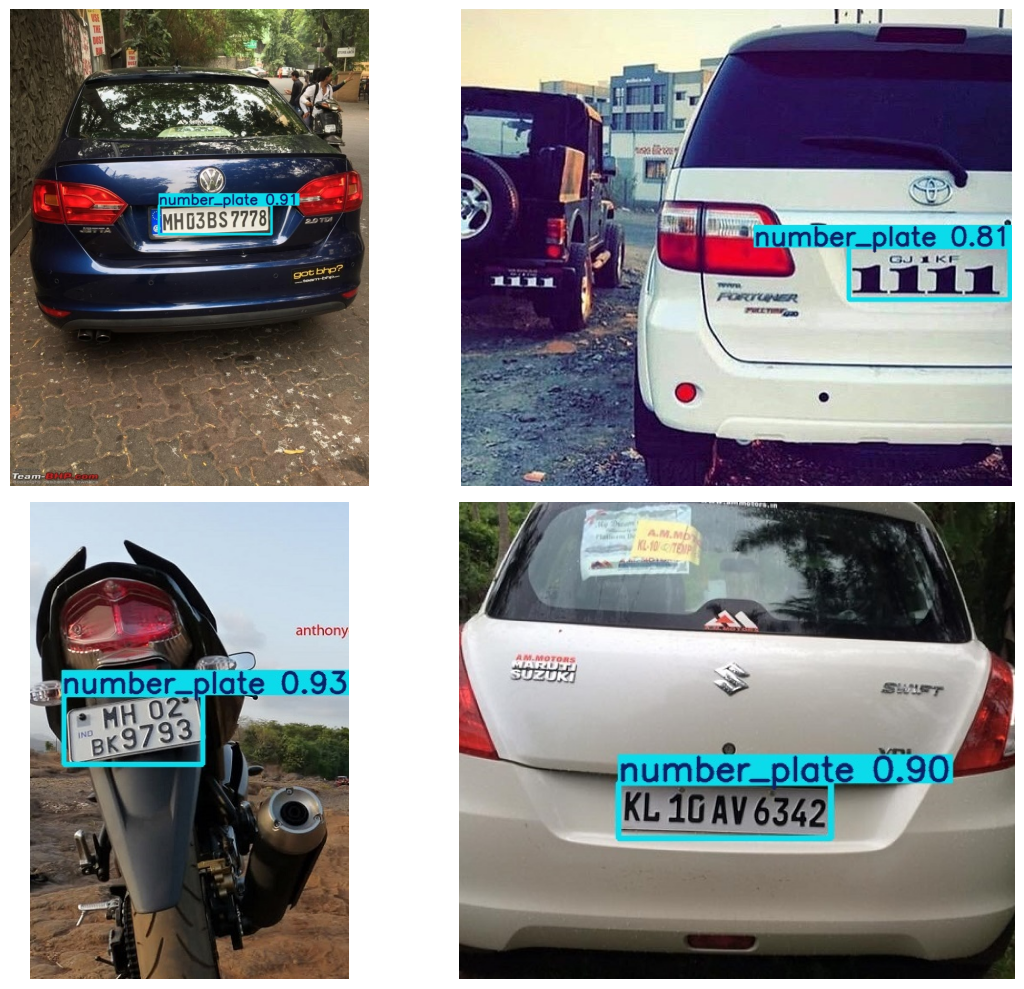

In [19]:
# displaying the first 4 inference results in a 2x2 grid
import matplotlib.image as mpimg

output_folder = "yolov5/runs/detect/plate_inference/"

result_images = [f for f in os.listdir(output_folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))][:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, img_name in zip(axes.flatten(), result_images):
    img_path = os.path.join(output_folder, img_name)
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Task 16: Evaluate on the Test Set

In [20]:
# evaluating the model on the test set
!python yolov5/val.py \
    --weights yolov5/runs/train/plate_run/weights/best.pt \
    --data plate_detection.yaml \
    --img 416 \
    --task test

val: data=plate_detection.yaml, weights=['yolov5/runs/train/plate_run/weights/best.pt'], batch_size=32, imgsz=416, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=yolov5/runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-509-gfd0f6da7 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /LicensePlateDetection/labels/test... 78 images, 0 backgrounds, 0 corrupt: 100% 78/78 [00:00<00:00, 934.07it/s]
test: New cache created: /LicensePlateDetection/labels/test.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 3/3 [00:02<00:00,  1.16it/s]
                   all         78         78       0.98      0.492      0.529      0.397
             num_plate         

## Stage 4: Deployment — Export to ONNX


### Task 17: Export the Trained Weights to ONNX

In [21]:
# exporting best.pt to ONNX
!pip install -q onnx onnx-simplifier

!python yolov5/export.py \
    --weights yolov5/runs/train/plate_run/weights/best.pt \
    --img 416 \
    --include onnx \
    --simplify \
    --opset 12

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 98.8 MB/s eta 0:00:00
export: data=yolov5/data/coco128.yaml, weights=['yolov5/runs/train/plate_run/weights/best.pt'], imgsz=[416], batch_size=1, device=cpu, half=False, inplace=False, keras=False, optimize=False, int8=False, per_tensor=False, dynamic=False, cache=, simplify=True, mlmodel=False, opset=12, verbose=False, workspace=4, nms=False, agnostic_nms=False, topk_per_class=100, topk_all=100, iou_thres=0.45, conf_thres=0.25, include=['onnx']
YOLOv5 🚀 v7.0-509-gfd0f6da7 Python-3.12.13 torch-2.11.0+cu128 CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs

PyTorch: starting from yolov5/runs/train/plate_run/weights/best.pt with output shape (1, 10647, 7) (13.7 MB)
requirements: U

### Task 18: Sanity-Check the ONNX Model in Python


In [22]:
# running the ONNX model with onnxruntime and comparing it against detect.py
import onnxruntime as ort
import cv2

onnx_path = "yolov5/runs/train/plate_run/weights/best.onnx"
session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])

input_name = session.get_inputs()[0].name
input_shape = session.get_inputs()[0].shape
print("Input:", input_name, input_shape)
print("Output:", [o.name for o in session.get_outputs()], session.get_outputs()[0].shape)

img_size = input_shape[-1]
test_img_name = os.listdir("/LicensePlateDetection/images/test/")[0]
test_img_path = os.path.join("/LicensePlateDetection/images/test/", test_img_name)

img = cv2.imread(test_img_path)
img_resized = cv2.resize(img, (img_size, img_size))
blob = img_resized[:, :, ::-1].transpose(2, 0, 1).astype(np.float32) / 255.0
blob = np.expand_dims(blob, axis=0)

outputs = session.run(None, {input_name: blob})
preds = outputs[0][0]  # (num_boxes, 6)

# Keep only boxes above a confidence threshold, for a quick sanity check
conf_mask = preds[:, 4] > 0.4
print(f"{conf_mask.sum()} boxes above 0.4 objectness confidence")

Input: images [1, 3, 416, 416]
Output: ['output0'] [1, 10647, 7]
9 boxes above 0.4 objectness confidence


### Task 19: Build the ONNX Runtime Web Frontend

In [26]:
# writing the Streamlit app files to disk
os.makedirs("streamlit_app", exist_ok=True)
shutil.copy("yolov5/runs/train/plate_run/weights/best.onnx", "streamlit_app/best.onnx")

app_py = r"""
import io
import time
import os
import numpy as np
import onnxruntime as ort
import streamlit as st
from PIL import Image, ImageDraw, ImageFont


BASE_DIR = os.path.dirname(os.path.abspath(__file__))
MODEL_PATH = os.path.join(BASE_DIR, "best.onnx")
CLASS_NAMES = ["num_plate", "number_plate"]
DEFAULT_CONF = 0.40
IOU_THRESHOLD = 0.45

st.set_page_config(page_title="Plate Finder", page_icon="🚗", layout="centered")



@st.cache_resource
def load_model(model_path):
    session = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
    input_meta = session.get_inputs()[0]
    input_size = input_meta.shape[-1] if isinstance(input_meta.shape[-1], int) else 416
    return session, input_size



def letterbox(img: Image.Image, size: int):
    w, h = img.size
    scale = min(size / w, size / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    pad_x, pad_y = (size - new_w) // 2, (size - new_h) // 2

    resized = img.resize((new_w, new_h), Image.BILINEAR)
    canvas = Image.new("RGB", (size, size), (114, 114, 114))
    canvas.paste(resized, (pad_x, pad_y))
    return canvas, scale, pad_x, pad_y


def image_to_tensor(img: Image.Image):
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = arr.transpose(2, 0, 1)
    return np.expand_dims(arr, axis=0)



def iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter + 1e-9)


def nms(boxes, iou_thresh):
    boxes = sorted(boxes, key=lambda b: b["score"], reverse=True)
    keep = []
    for b in boxes:
        if all(not (b["cls"] == k["cls"] and iou(b["xyxy"], k["xyxy"]) > iou_thresh) for k in keep):
            keep.append(b)
    return keep


def decode_output(output, conf_thresh, scale, pad_x, pad_y):

    preds = output[0]
    expected_dim = 5 + len(CLASS_NAMES)
    if preds.shape[-1] != expected_dim and preds.shape[0] == expected_dim:
        preds = preds.T

    num_classes = preds.shape[1] - 5

    objectness = preds[:, 4]
    class_scores = preds[:, 5:5 + num_classes]
    best_cls = np.argmax(class_scores, axis=1)
    best_score = class_scores[np.arange(len(preds)), best_cls]
    conf = objectness * best_score

    mask = conf > conf_thresh
    boxes = []
    for row, cls_id, score in zip(preds[mask], best_cls[mask], conf[mask]):
        cx, cy, w, h = row[:4]
        x1 = (cx - w / 2 - pad_x) / scale
        y1 = (cy - h / 2 - pad_y) / scale
        x2 = (cx + w / 2 - pad_x) / scale
        y2 = (cy + h / 2 - pad_y) / scale
        boxes.append({"xyxy": (x1, y1, x2, y2), "score": float(score), "cls": int(cls_id)})
    return boxes


def draw_boxes(img: Image.Image, boxes):
    img = img.copy()
    draw = ImageDraw.Draw(img)
    line_w = max(2, img.width // 250)
    try:
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", size=max(14, img.width // 45))
    except OSError:
        font = ImageFont.load_default()

    for b in boxes:
        x1, y1, x2, y2 = b["xyxy"]
        label = f'{CLASS_NAMES[b["cls"]]} {b["score"] * 100:.0f}%'
        draw.rectangle([x1, y1, x2, y2], outline="#f4b400", width=line_w)
        text_bbox = draw.textbbox((0, 0), label, font=font)
        text_w, text_h = text_bbox[2] - text_bbox[0] + 10, text_bbox[3] - text_bbox[1] + 8
        draw.rectangle([x1 - line_w / 2, y1 - text_h, x1 - line_w / 2 + text_w, y1], fill="#f4b400")
        draw.text((x1 + 5, y1 - text_h + 2), label, fill="#16241f", font=font)
    return img

# UI
st.title("🚗 Plate Finder")
st.caption("YOLOv5, exported to ONNX, running server-side via onnxruntime.")

try:
    session, model_input_size = load_model(MODEL_PATH)
    st.success(f"Model loaded — input size {model_input_size}×{model_input_size}", icon="✅")
except Exception as e:
    st.error(f"Could not load `{MODEL_PATH}`. Make sure it sits next to this script.\n\n{e}")
    st.stop()

conf_thresh = st.slider("Confidence threshold", 0.05, 0.90, DEFAULT_CONF, 0.05)

uploaded_file = st.file_uploader("Upload a photo of a vehicle", type=["png", "jpg", "jpeg", "webp"])

if uploaded_file is not None:
    img = Image.open(io.BytesIO(uploaded_file.read())).convert("RGB")

    t0 = time.time()
    canvas, scale, pad_x, pad_y = letterbox(img, model_input_size)
    tensor = image_to_tensor(canvas)

    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name
    output = session.run([output_name], {input_name: tensor})[0]

    boxes = decode_output(output, conf_thresh, scale, pad_x, pad_y)
    boxes = nms(boxes, IOU_THRESHOLD)
    elapsed_ms = (time.time() - t0) * 1000

    annotated = draw_boxes(img, boxes)
    st.image(annotated, use_container_width=True)
    st.caption(f"{len(boxes)} detection(s) · {elapsed_ms:.0f} ms")

    if boxes:
        st.subheader("Detections")
        st.table([
            {
                "class": CLASS_NAMES[b["cls"]],
                "confidence": f'{b["score"] * 100:.1f}%',
                "box (x1, y1, x2, y2)": tuple(round(v, 1) for v in b["xyxy"]),
            }
            for b in boxes
        ])
    else:
        st.info("No plate found above the current confidence threshold — try lowering it.")
else:
    st.info("Upload an image to run detection.")
"""

requirements_txt = r"""
streamlit
onnxruntime
numpy
pillow
"""

with open("streamlit_app/app.py", "w") as f:
    f.write(app_py)

with open("streamlit_app/requirements.txt", "w") as f:
    f.write(requirements_txt)

shutil.make_archive("streamlit_app", "zip", "streamlit_app")

print(os.listdir("streamlit_app"))

['requirements.txt', 'best.onnx', 'app.py']


The trained model is deployed as a public Streamlit app:

https://licenseplatedetectionyolov5-kxardcdpappnkapda7nzmfr.streamlit.app/